# Discrete Elastic Shells: Simple Example with Four Nodes
Copyright M. Khalid Jawed (khalidjm@seas.ucla.edu). License: CC BY-NC
You should use this code at your own risk.

#Load Libraries

In [196]:
from IPython.display import clear_output
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

#Miscellaneous Functions: signedAngle, rotateAxisAngle, parallel_transport, crossMat

In [197]:
def signedAngle(u = None,v = None,n = None):
    # This function calculates the signed angle between two vectors, "u" and "v",
    # using an optional axis vector "n" to determine the direction of the angle.
    #
    # Parameters:
    #   u: numpy array-like, shape (3,), the first vector.
    #   v: numpy array-like, shape (3,), the second vector.
    #   n: numpy array-like, shape (3,), the axis vector that defines the plane
    #      in which the angle is measured. It determines the sign of the angle.
    #
    # Returns:
    #   angle: float, the signed angle (in radians) from vector "u" to vector "v".
    #          The angle is positive if the rotation from "u" to "v" follows
    #          the right-hand rule with respect to the axis "n", and negative otherwise.
    #
    # The function works by:
    # 1. Computing the cross product "w" of "u" and "v" to find the vector orthogonal
    #    to both "u" and "v".
    # 2. Calculating the angle between "u" and "v" using the arctan2 function, which
    #    returns the angle based on the norm of "w" (magnitude of the cross product)
    #    and the dot product of "u" and "v".
    # 3. Using the dot product of "n" and "w" to determine the sign of the angle.
    #    If this dot product is negative, the angle is adjusted to be negative.
    #
    # Example:
    #   signedAngle(np.array([1, 0, 0]), np.array([0, 1, 0]), np.array([0, 0, 1]))
    #   This would return a positive angle (π/2 radians), as the rotation
    #   from the x-axis to the y-axis is counterclockwise when viewed along the z-axis.
    w = np.cross(u,v)
    angle = np.arctan2( np.linalg.norm(w), np.dot(u,v) )
    if (np.dot(n,w) < 0):
        angle = - angle

    return angle

In [198]:
def mmt(matrix):
    return matrix + matrix.T

# Hinge angle, its gradient, and Hessian

In [199]:
#          x2
#          /\
#         /  \
#      e1/    \e3
#       /  t0  \
#      /        \
#     /    e0    \
#   x0------------x1
#     \          /
#      \   t1   /
#       \      /
#      e2\    /e4
#         \  /
#          \/
#          x3
#
#  Edge orientation: e0,e1,e2 point away from x0
#                       e3,e4 point away from x1

In [200]:
def getTheta(x0, x1 = None, x2 = None, x3 = None):

    if np.size(x0) == 12:  # Allow another type of input where x0 contains all the info
      x1 = x0[3:6]
      x2 = x0[6:9]
      x3 = x0[9:12]
      x0 = x0[0:3]

    m_e0 = x1 - x0
    m_e1 = x2 - x0
    m_e2 = x3 - x0

    n0 = np.cross(m_e0, m_e1)
    n1 = np.cross(m_e2, m_e0)

    # Calculate the signed angle using the provided function
    theta = signedAngle(n0, n1, m_e0)

    return theta

In [201]:
# In the original code, there are probaly TWO sign errors in the expressions for m_h3 and m_h4.
# [Original code: % https://github.com/shift09/plates-shells/blob/master/src/bending.cpp]
# I indicated those two corrections by writing the word "CORRECTION" next
# to them.

def gradTheta(x0, x1 = None, x2 = None, x3 = None):

    if np.size(x0) == 12:  # Allow another type of input where x0 contains all the info
      x1 = x0[3:6]
      x2 = x0[6:9]
      x3 = x0[9:12]
      x0 = x0[0:3]

    m_e0 = x1 - x0
    m_e1 = x2 - x0
    m_e2 = x3 - x0
    m_e3 = x2 - x1
    m_e4 = x3 - x1

    m_cosA1 = np.dot(m_e0, m_e1) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e1))
    m_cosA2 = np.dot(m_e0, m_e2) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e2))
    m_cosA3 = -np.dot(m_e0, m_e3) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e3))
    m_cosA4 = -np.dot(m_e0, m_e4) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e4))

    m_sinA1 = np.linalg.norm(np.cross(m_e0, m_e1)) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e1))
    m_sinA2 = np.linalg.norm(np.cross(m_e0, m_e2)) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e2))
    m_sinA3 = -np.linalg.norm(np.cross(m_e0, m_e3)) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e3))
    m_sinA4 = -np.linalg.norm(np.cross(m_e0, m_e4)) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e4))

    m_nn1 = np.cross(m_e0, m_e3)
    m_nn1 = m_nn1 / np.linalg.norm(m_nn1)
    m_nn2 = -np.cross(m_e0, m_e4)
    m_nn2 = m_nn2 / np.linalg.norm(m_nn2)

    m_h1 = np.linalg.norm(m_e0) * m_sinA1
    m_h2 = np.linalg.norm(m_e0) * m_sinA2
    m_h3 = -np.linalg.norm(m_e0) * m_sinA3  # CORRECTION
    m_h4 = -np.linalg.norm(m_e0) * m_sinA4  # CORRECTION
    m_h01 = np.linalg.norm(m_e1) * m_sinA1
    m_h02 = np.linalg.norm(m_e2) * m_sinA2

    # Initialize the gradient
    gradTheta = np.zeros(12)

    gradTheta[0:3] = m_cosA3 * m_nn1 / m_h3 + m_cosA4 * m_nn2 / m_h4
    gradTheta[3:6] = m_cosA1 * m_nn1 / m_h1 + m_cosA2 * m_nn2 / m_h2
    gradTheta[6:9] = -m_nn1 / m_h01
    gradTheta[9:12] = -m_nn2 / m_h02

    return gradTheta

In [202]:
def hessTheta(x0, x1 = None, x2 = None, x3 = None):

    if np.size(x0) == 12:  # Allow another type of input where x0 contains all the info
      x1 = x0[3:6]
      x2 = x0[6:9]
      x3 = x0[9:12]
      x0 = x0[0:3]

    m_e0 = x1 - x0
    m_e1 = x2 - x0
    m_e2 = x3 - x0
    m_e3 = x2 - x1
    m_e4 = x3 - x1

    m_cosA1 = np.dot(m_e0, m_e1) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e1))
    m_cosA2 = np.dot(m_e0, m_e2) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e2))
    m_cosA3 = -np.dot(m_e0, m_e3) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e3))
    m_cosA4 = -np.dot(m_e0, m_e4) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e4))

    m_sinA1 = np.linalg.norm(np.cross(m_e0, m_e1)) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e1))
    m_sinA2 = np.linalg.norm(np.cross(m_e0, m_e2)) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e2))
    m_sinA3 = -np.linalg.norm(np.cross(m_e0, m_e3)) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e3))
    m_sinA4 = -np.linalg.norm(np.cross(m_e0, m_e4)) / (np.linalg.norm(m_e0) * np.linalg.norm(m_e4))

    m_nn1 = np.cross(m_e0, m_e3)
    m_nn1 /= np.linalg.norm(m_nn1)
    m_nn2 = -np.cross(m_e0, m_e4)
    m_nn2 /= np.linalg.norm(m_nn2)

    m_h1 = np.linalg.norm(m_e0) * m_sinA1
    m_h2 = np.linalg.norm(m_e0) * m_sinA2
    m_h3 = -np.linalg.norm(m_e0) * m_sinA3
    m_h4 = -np.linalg.norm(m_e0) * m_sinA4
    m_h01 = np.linalg.norm(m_e1) * m_sinA1
    m_h02 = np.linalg.norm(m_e2) * m_sinA2

    # Gradient of Theta (as an intermediate step)
    grad_theta = np.zeros((12, 1))
    grad_theta[0:3] = (m_cosA3 * m_nn1 / m_h3 + m_cosA4 * m_nn2 / m_h4).reshape(-1, 1)
    grad_theta[3:6] = (m_cosA1 * m_nn1 / m_h1 + m_cosA2 * m_nn2 / m_h2).reshape(-1, 1)
    grad_theta[6:9] = (-m_nn1 / m_h01).reshape(-1, 1)
    grad_theta[9:12] = (-m_nn2 / m_h02).reshape(-1, 1)

    # Intermediate matrices for Hessian
    m_m1 = np.cross(m_nn1, m_e1) / np.linalg.norm(m_e1)
    m_m2 = -np.cross(m_nn2, m_e2) / np.linalg.norm(m_e2)
    m_m3 = -np.cross(m_nn1, m_e3) / np.linalg.norm(m_e3)
    m_m4 = np.cross(m_nn2, m_e4) / np.linalg.norm(m_e4)
    m_m01 = -np.cross(m_nn1, m_e0) / np.linalg.norm(m_e0)
    m_m02 = np.cross(m_nn2, m_e0) / np.linalg.norm(m_e0)

    # Hessian matrix components
    M331 = m_cosA3 / (m_h3 ** 2) * np.outer(m_m3, m_nn1)
    M311 = m_cosA3 / (m_h3 * m_h1) * np.outer(m_m1, m_nn1)
    M131 = m_cosA1 / (m_h1 * m_h3) * np.outer(m_m3, m_nn1)
    M3011 = m_cosA3 / (m_h3 * m_h01) * np.outer(m_m01, m_nn1)
    M111 = m_cosA1 / (m_h1 ** 2) * np.outer(m_m1, m_nn1)
    M1011 = m_cosA1 / (m_h1 * m_h01) * np.outer(m_m01, m_nn1)

    M442 = m_cosA4 / (m_h4 ** 2) * np.outer(m_m4, m_nn2)
    M422 = m_cosA4 / (m_h4 * m_h2) * np.outer(m_m2, m_nn2)
    M242 = m_cosA2 / (m_h2 * m_h4) * np.outer(m_m4, m_nn2)
    M4022 = m_cosA4 / (m_h4 * m_h02) * np.outer(m_m02, m_nn2)
    M222 = m_cosA2 / (m_h2 ** 2) * np.outer(m_m2, m_nn2)
    M2022 = m_cosA2 / (m_h2 * m_h02) * np.outer(m_m02, m_nn2)

    B1 = 1 / np.linalg.norm(m_e0) ** 2 * np.outer(m_nn1, m_m01)
    B2 = 1 / np.linalg.norm(m_e0) ** 2 * np.outer(m_nn2, m_m02)

    N13 = 1 / (m_h01 * m_h3) * np.outer(m_nn1, m_m3)
    N24 = 1 / (m_h02 * m_h4) * np.outer(m_nn2, m_m4)
    N11 = 1 / (m_h01 * m_h1) * np.outer(m_nn1, m_m1)
    N22 = 1 / (m_h02 * m_h2) * np.outer(m_nn2, m_m2)
    N101 = 1 / (m_h01 ** 2) * np.outer(m_nn1, m_m01)
    N202 = 1 / (m_h02 ** 2) * np.outer(m_nn2, m_m02)

    # Initialize Hessian of Theta
    hess_theta = np.zeros((12, 12))

    hess_theta[0:3, 0:3] = mmt(M331) - B1 + mmt(M442) - B2
    hess_theta[0:3, 3:6] = M311 + M131.T + B1 + M422 + M242.T + B2
    hess_theta[0:3, 6:9] = M3011 - N13
    hess_theta[0:3, 9:12] = M4022 - N24
    hess_theta[3:6, 3:6] = mmt(M111) - B1 + mmt(M222) - B2
    hess_theta[3:6, 6:9] = M1011 - N11
    hess_theta[3:6, 9:12] = M2022 - N22
    hess_theta[6:9, 6:9] = -mmt(N101)
    hess_theta[9:12, 9:12] = -mmt(N202)

    # Make the Hessian symmetric
    hess_theta[3:6, 0:3] = hess_theta[0:3, 3:6].T
    hess_theta[6:9, 0:3] = hess_theta[0:3, 6:9].T
    hess_theta[9:12, 0:3] = hess_theta[0:3, 9:12].T
    hess_theta[6:9, 3:6] = hess_theta[3:6, 6:9].T
    hess_theta[9:12, 3:6] = hess_theta[3:6, 9:12].T

    return hess_theta


# Stretching energy for a shell, it's gradient, and Hessian

In [203]:
def gradEs_hessEs(node0 = None,node1 = None,l_k = None,EA = None):

# Inputs:
# node0: 1x3 vector - position of the first node
# node1: 1x3 vector - position of the last node

# l_k: reference length (undeformed) of the edge
# EA: scalar - stretching stiffness - Young's modulus times area

# Outputs:
# dF: 6x1  vector - gradient of the stretching energy between node0 and node 1.
# dJ: 6x6 vector - hessian of the stretching energy between node0 and node 1.

    ## Gradient of Es
    edge = node1 - node0

    edgeLen = np.linalg.norm(edge)
    tangent = edge / edgeLen
    epsX = edgeLen / l_k - 1
    dF_unit = EA * tangent * epsX
    dF = np.zeros((6))
    dF[0:3] = - dF_unit
    dF[3:6] = dF_unit

    ## Hessian of Es
    Id3 = np.eye(3)
    M = EA * ((1 / l_k - 1 / edgeLen) * Id3 + 1 / edgeLen * ( np.outer( edge, edge ) ) / edgeLen ** 2)

    dJ = np.zeros((6,6))
    dJ[0:3,0:3] = M
    dJ[3:6,3:6] = M
    dJ[0:3,3:6] = - M
    dJ[3:6,0:3] = - M
    return dF,dJ

# Bending energy for a shell, it's gradient, and Hessian

In [204]:
def getEb_Shell(x0, x1=None, x2=None, x3=None, theta_bar=0, kb=1.0):
    """
    Compute the bending energy for a shell.

    Returns:
    E (scalar): Bending energy.
    """
    # Allow another type of input where x0 contains all the information
    if np.size(x0) == 12:
        x1 = x0[3:6]
        x2 = x0[6:9]
        x3 = x0[9:12]
        x0 = x0[:3]

    # Compute theta, gradient, and Hessian
    theta = getTheta(x0, x1, x2, x3)  # Replace with your getTheta function in Python
    grad = gradTheta(x0, x1, x2, x3)  # Replace with your gradTheta function in Python

    # E = 0.5 * kb * (theta-thetaBar)^2
    E = 0.5 * kb * (theta - theta_bar) ** 2

    return E

In [205]:
def gradEb_hessEb_Shell(x0, x1=None, x2=None, x3=None, theta_bar=0, kb=1.0):
    """
    Compute the gradient and Hessian of the bending energy for a shell.

    Parameters:
    x0 (array): Can either be a 3-element array (single point) or a 12-element array.
    x1, x2, x3 (arrays): Optional, 3-element arrays specifying points.
    theta_bar (float): Reference angle.
    kb (float): Bending stiffness.

    Returns:
    dF (array): Gradient of the bending energy.
    dJ (array): Hessian of the bending energy.
    """
    # Allow another type of input where x0 contains all the information
    if np.size(x0) == 12:
        x1 = x0[3:6]
        x2 = x0[6:9]
        x3 = x0[9:12]
        x0 = x0[:3]

    # Compute theta, gradient, and Hessian
    theta = getTheta(x0, x1, x2, x3)  # Replace with your getTheta function in Python
    grad = gradTheta(x0, x1, x2, x3)  # Replace with your gradTheta function in Python

    # E = 0.5 * kb * (theta-thetaBar)^2
    # F = dE/dx = 2 * (theta-thetaBar) * gradTheta
    dF = 0.5 * kb * (2 * (theta - theta_bar) * grad)

    # E = 0.5 * kb * (theta-thetaBar)^2
    # F = 0.5 * kb * (2 (theta-thetaBar) d theta/dx)
    # J = dF/dx = 0.5 * kb * [ 2 (d theta / dx) transpose(d theta/dx) +
    #       2 (theta-thetaBar) (d^2 theta/ dx^2 ) ]
    hess = hessTheta(x0, x1, x2, x3)  # Replace with your hessTheta function in Python
    dJ = 0.5 * kb * (2 * np.outer(grad, grad) + 2 * (theta - theta_bar) * hess)

    return dF, dJ

#Plot the shell

In [206]:
# Function to set equal aspect ratio for 3D plots
def set_axes_equal(ax):
    """
    Set equal aspect ratio for a 3D plot in Matplotlib.
    This function adjusts the limits of the plot to make sure
    that the scale is equal along all three axes.
    """
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    max_range = max(x_range, y_range, z_range)

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    ax.set_xlim3d([x_middle - max_range / 2, x_middle + max_range / 2])
    ax.set_ylim3d([y_middle - max_range / 2, y_middle + max_range / 2])
    ax.set_zlim3d([z_middle - max_range / 2, z_middle + max_range / 2])

In [207]:
def plotShell(q, ctime, nodes, edges, fixed_nodes=None):
    """
    General 3D plotting function for HW5 discrete shell.
    
    q: (3*nv,) DOF vector
    nodes: (nv,3) array of node positions (reference shape)
    edges: (ne,2) connectivity list
    fixed_nodes: list of indices of fixed nodes
    """
    nv = nodes.shape[0]
    pts = q.reshape((nv, 3))   # reshape into (x,y,z)

    clear_output(wait=True)
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection='3d')

    # ---- draw edges ----
    for (i, j) in edges:
        xi, yi, zi = pts[i]
        xj, yj, zj = pts[j]
        ax.plot([xi, xj], [yi, yj], [zi, zj], 'k-', lw=1.0)

    # ---- draw nodes ----
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], c='k', s=25)

    # ---- draw fixed nodes ----
    if fixed_nodes is not None:
        fixed_nodes = np.array(fixed_nodes, dtype=int)
        ax.scatter(
            pts[fixed_nodes, 0],
            pts[fixed_nodes, 1],
            pts[fixed_nodes, 2],
            c='r', s=60, marker='^'
        )

    # ---- labels and title ----
    ax.set_title(f"t = {ctime:.2f} s")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    ax.set_box_aspect((1,0.2,0.2))  # optional: stretch aspect for visibility

    plt.show()

# Objective function

In [208]:
def objfun(qOld, uOld, freeIndex, dt, tol, massVector, massMatrix,
           ks, refLen, edges,
           kb, thetaBar, hinges,
           Fg, visc):

  qNew = qOld.copy()
  ndof = len(qOld) # Number of DOFs

  iter = 0 # number of iteration
  error = 10 * tol
  # Newton Raphson
  while error > tol:

    # Bending force and jacobian
    Fb = np.zeros( ndof )
    Jb = np.zeros( (ndof,ndof) )
    # Loop over every "bending spring" or "hinge"
    for kHinge in range(hinges.shape[0]):
      node0 = hinges[kHinge, 0]
      node1 = hinges[kHinge, 1]
      node2 = hinges[kHinge, 2]
      node3 = hinges[kHinge, 3]
      x0 = qNew[ 3*node0: 3*node0 + 3]
      x1 = qNew[ 3*node1: 3*node1 + 3]
      x2 = qNew[ 3*node2: 3*node2 + 3]
      x3 = qNew[ 3*node3: 3*node3 + 3]
      ind = [3*node0, 3*node0 + 1, 3*node0 + 2,
             3*node1, 3*node1 + 1, 3*node1 + 2,
             3*node2, 3*node2 + 1, 3*node2 + 2,
             3*node3, 3*node3 + 1, 3*node3 + 2]
      dF, dJ = gradEb_hessEb_Shell(x0, x1, x2, x3, 0, kb)
      Fb[ind] -= dF
      Jb[np.ix_(ind,ind)] -= dJ

    # Stretching force and jacobian
    Fs = np.zeros( ndof )
    Js = np.zeros( (ndof,ndof) )
    for kEdge in range(edges.shape[0]):
      node0 = edges[kEdge, 0]
      node1 = edges[kEdge, 1]
      x0 = qNew[ 3*node0: 3*node0 + 3]
      x1 = qNew[ 3*node1: 3*node1 + 3]
      ind = [3*node0, 3*node0 + 1, 3*node0 + 2,
             3*node1, 3*node1 + 1, 3*node1 + 2]
      dF, dJ = gradEs_hessEs(x0, x1, refLen[kEdge], ks[kEdge])
      Fs[ind] -= dF
      Js[np.ix_(ind,ind)] -= dJ

    # Viscous force
    Fv = - visc * (qNew - qOld) / dt
    Jv = - visc / dt * np.eye(ndof)

    Forces = Fb + Fs + Fg + Fv # Sum of forces
    JForces = Jb + Js + Jv # Sum of Jacobians

    # Set up my equations of motion and calculating its residual (=0)
    f = massVector / dt * ( (qNew - qOld)/dt - uOld) - Forces # Residual of EOM
    J = massMatrix / dt ** 2 - JForces

    # Extract the free part of the f and J arrays
    f_free = f[freeIndex]
    J_free = J[np.ix_(freeIndex, freeIndex)]
    # Correction
    dq_free = np.linalg.solve(J_free, f_free)

    # Update my guess for position
    qNew[freeIndex] -= dq_free

    # Calculate error
    error = np.sum( np.abs(f_free))

    iter += 1

    print('Iter = ', iter, ' error=', error)

  uNew = (qNew - qOld) / dt
  return qNew, uNew

#Main Discrete Shells

**DOFs and Nodes**

In [209]:

# ---------------- Nodes (20) ----------------
x_cols = np.array([-0.0125, 0.0, 0.0125, 0.025, 0.0375, 0.05,
                   0.0625, 0.075, 0.0875, 0.1])
y_rows = np.array([0.0, 0.01])

nodes = []
for y in y_rows:
    for x in x_cols:
        nodes.append([x, y, 0.0])
nodes = np.array(nodes)

nv   = nodes.shape[0]        # 20
ndof = 3 * nv
qOld = nodes.reshape(-1)

**Springs: Create edges (stretching) and hinges (bending)**

In [210]:
faces = []
def nid(r, c): return r*10 + c

for c in range(9):
    b0 = nid(0, c)
    b1 = nid(0, c+1)
    t0 = nid(1, c)
    t1 = nid(1, c+1)

    if c % 2 == 0:
        # EVEN cell: diagonal b0 -> t1
        faces.append([b0, b1, t1])
        faces.append([b0, t1, t0])
    else:
        # ODD cell: diagonal t0 -> b1
        faces.append([t0, t1, b1])
        faces.append([t0, b1, b0])

faces = np.array(faces, dtype=int)

# ---------------- Edges extracted from faces ----------------
edge_set = set()
for tri in faces:
    for a, b in [(tri[0], tri[1]), (tri[1], tri[2]), (tri[2], tri[0])]:
        edge_set.add(tuple(sorted((a, b))))
edges = np.array(sorted(edge_set), dtype=int)

# ---------------- Hinges extracted from shared edges ----------------
edge_to_faces = defaultdict(list)
for f_id, tri in enumerate(faces):
    tri_edges = [
        tuple(sorted((tri[0], tri[1]))),
        tuple(sorted((tri[1], tri[2]))),
        tuple(sorted((tri[2], tri[0])))
    ]
    for e in tri_edges:
        edge_to_faces[e].append(f_id)

hinges = []
for e, adj in edge_to_faces.items():
    if len(adj) == 2:     # shared by exactly two triangles
        f0, f1 = adj
        t0, t1 = faces[f0], faces[f1]

        i, j = e
        k0 = [v for v in t0 if v not in e][0]
        k1 = [v for v in t1 if v not in e][0]

        hinges.append([i, j, k0, k1])

hinges = np.array(hinges, dtype=int)

**Elastic Stiffness**

In [211]:
Y = 1.0e7 # Young's modulus in Pa
h = 0.002 # Thickness in meter

# Stiffness variables
kb = 2.0 / np.sqrt(3.0) * Y * h**3.0 / 12 # Bending stiffness (Newton-meter)
refLen = np.zeros(edges.shape[0]) # reference length, denoted as l_k
ks = np.zeros_like(refLen) # Stretching stiffness
for kEdge in range(edges.shape[0]):
  node0 = edges[kEdge, 0]
  node1 = edges[kEdge, 1]
  x0 = qOld[ 3*node0: 3*node0 + 3]
  x1 = qOld[ 3*node1: 3*node1 + 3]
  refLen[kEdge] = np.linalg.norm(x1 - x0)
  ks[kEdge] = np.sqrt(3.0) / 2.0 * Y * h * (refLen[kEdge]) ** 2

**Time parameters**

In [212]:
totalTime = 20 # seconds
dt = 0.001 # time step sie

tol = kb / (0.01) * 1e-3 # Approximate tolerance

**Mass Vector and Matrix**

In [213]:
rho = 1000.0
w   = 0.01
h   = 0.002
A   = w * h
L   = 0.1

# ----- total physical mass -----
totalM = rho * A * L
print("Total mass:", totalM)   # 0.002 kg

# ----- lump mass equally to each of the 20 nodes -----
m_node = np.ones(nv) * (totalM / nv)

# ----- build massVector with 3 DOF per node -----
massVector = np.zeros(ndof)
for c in range(nv):
    massVector[3*c : 3*c+3] = m_node[c]

massMatrix = np.diag(massVector)


Total mass: 0.002


**External force**

In [214]:
g = np.array([0, 0, -9.8])
Fg = np.zeros(ndof)
for c in range(nv):
  ind = [3*c, 3*c+1, 3*c+2]
  Fg[ind] = massVector[ind] * g

**Natural curvature**

In [215]:
thetaBar = getTheta(x0, x1, x2, x3) # getTheta(qOld)

**Boundary conditions and Initial Conditions**

In [216]:
uOld = np.zeros(ndof)   # initial velocities

# ---- fixed nodes: all nodes with x <= 0 ----
fixed_nodes = []
for i, (x, y, z) in enumerate(nodes):
    if x <= 0.0 + 1e-12:   # left two columns
        fixed_nodes.append(i)

print("fixed nodes:", fixed_nodes)  # should be [0, 1, 10, 11]

# ---- build fixed DOF indices (3 DOFs per node) ----
fixedIndex = []
for v in fixed_nodes:
    fixedIndex.extend([3*v, 3*v+1, 3*v+2])

fixedIndex = np.array(fixedIndex, dtype=int)

# ---- free DOFs ----
all_idx   = np.arange(ndof)
freeIndex = np.setdiff1d(all_idx, fixedIndex)

print("Number of fixed DOFs:", len(fixedIndex))
print("Number of free DOFs:", len(freeIndex))


fixed nodes: [0, 1, 10, 11]
Number of fixed DOFs: 12
Number of free DOFs: 48


**Time stepping loop**

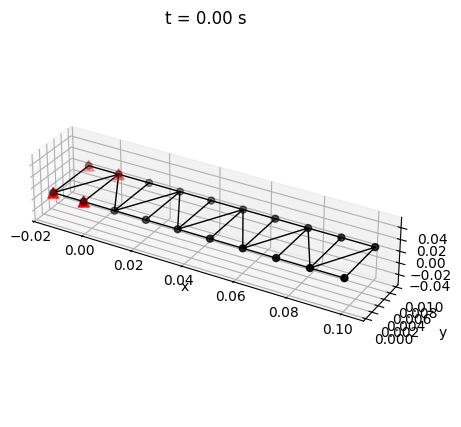

In [217]:
# Number of time steps
Nsteps = round(totalTime / dt)
ctime = 0.0       # Current time
endZ = np.zeros(Nsteps)

# ------------------ INITIAL PLOT (t = 0) ------------------
plotShell(qOld, ctime, nodes, edges, fixed_nodes)

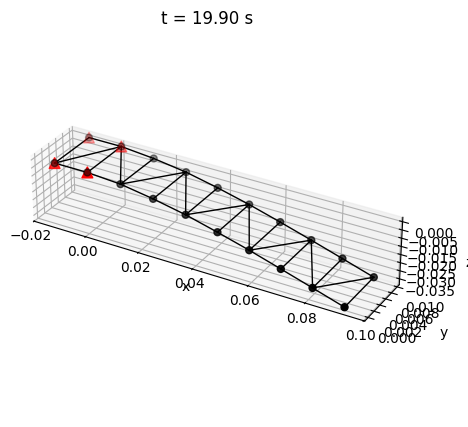

Current time = 19.9010
Iter =  1  error= 0.0012776448970565964
Iter =  2  error= 5.509605255225636e-09
Current time = 19.9020
Iter =  1  error= 0.0015016427022244304
Iter =  2  error= 7.615879035082667e-09
Current time = 19.9030
Iter =  1  error= 0.001724917521805619
Iter =  2  error= 1.0054029584007318e-08
Current time = 19.9040
Iter =  1  error= 0.0019473761971120335
Iter =  2  error= 1.281951802175856e-08
Current time = 19.9050
Iter =  1  error= 0.002168925954294903
Iter =  2  error= 1.5907318727876376e-08
Current time = 19.9060
Iter =  1  error= 0.0023894744450596137
Iter =  2  error= 1.9311895514897377e-08
Current time = 19.9070
Iter =  1  error= 0.0026089297881141823
Iter =  2  error= 2.3027120170490524e-08
Current time = 19.9080
Iter =  1  error= 0.0028272006096935857
Iter =  2  error= 2.704644050154496e-08
Current time = 19.9090
Iter =  1  error= 0.0030441960828978933
Iter =  2  error= 3.1362765283737994e-08
Current time = 19.9100
Iter =  1  error= 0.0032598259663884697
Iter = 

In [218]:
# ------------------ TIME STEPPING LOOP --------------------
for timeStep in range(Nsteps):
    print(f"Current time = {ctime:.4f}")

    # Newton update
    qNew, uNew = objfun(
        qOld, uOld, freeIndex,
        dt, tol, massVector, massMatrix,
        ks, refLen, edges,
        kb, thetaBar, hinges,
        Fg, visc
    )

    # advance time
    ctime += dt

    # update states
    qOld = qNew.copy()
    uOld = uNew.copy()

    # store tip z displacement
    endZ[timeStep] = qNew[-1]

    # plot every 100 steps
    if timeStep % 100 == 0:
        plotShell(qOld, ctime, nodes, edges, fixed_nodes)

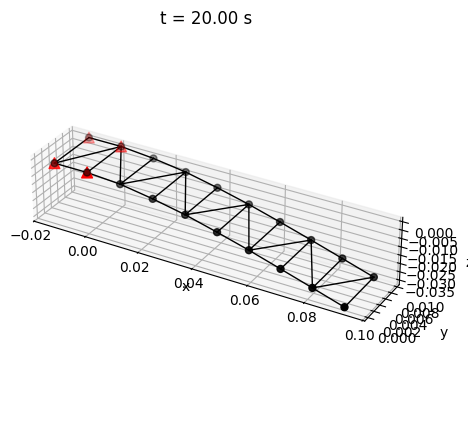

In [219]:
# ------------------ FINAL PLOT (t = totalTime) ------------------
plotShell(qOld, ctime, nodes, edges, fixed_nodes)

In [220]:
# --- Euler–Bernoulli tip displacement ---

rho = 1000.0
w   = 0.01
h   = 0.002
L   = 0.1
Y   = 1.0e7
g0  = 9.81

A = w * h
I = w * h**3 / 12.0
q = rho * A * g0          # N/m

delta_EB = q * L**4 / (8.0 * Y * I)
print("q =", q, "N/m")
print("I =", I, "m^4")
print("delta_EB =", delta_EB, "m")


q = 0.1962 N/m
I = 6.666666666666667e-12 m^4
delta_EB = 0.03678750000000001 m


In [221]:
# --- Plate steady displacement ---
delta_plate = endZ[-1]
print("delta_plate =", delta_plate, "m")
norm_diff = abs(abs(delta_plate) - delta_EB) / delta_EB

print("Normalized difference =", norm_diff)


delta_plate = -0.03519568730422328 m
Normalized difference = 0.04327047762899696


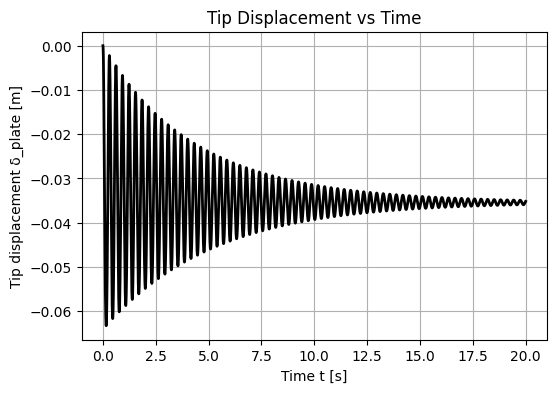

In [222]:
# --- Plot delta_plate vs time ---
time = np.linspace(0, totalTime, Nsteps)

plt.figure(figsize=(6,4))
plt.plot(time, endZ, 'k-', linewidth=2)
plt.xlabel("Time t [s]")
plt.ylabel("Tip displacement δ_plate [m]")
plt.title("Tip Displacement vs Time")
plt.grid(True)
plt.show()


In [228]:
# --- steady state detection (1% change over 1 second) ---

one_sec_steps = int(1.0 / dt)

steady_index = None
for k in range(one_sec_steps, Nsteps):
    delta_now  = endZ[k]
    delta_prev = endZ[k - one_sec_steps]

    # avoid division by zero
    if abs(delta_now) < 1e-12:
        continue

    rel_change = abs(delta_now - delta_prev) / abs(delta_now)

    if rel_change < 0.0001:   # < 0.01% change
        steady_index = k
        break

if steady_index is None:
    print("System did NOT reach steady state within the simulation time.")
else:
    print(f"Steady state detected at time t = {steady_index*dt:.3f} s")

delta_steady = endZ[steady_index] if steady_index is not None else None
print("Steady value δ* =", delta_steady)


Steady state detected at time t = 8.053 s
Steady value δ* = -0.030660317402109307


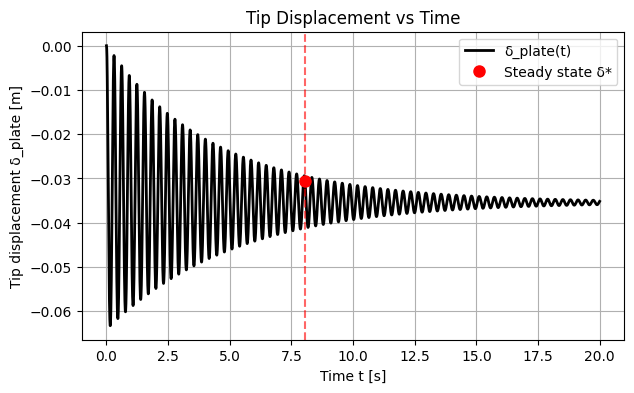

In [229]:
# --- Plot δ vs time and mark steady state ---

plt.figure(figsize=(7,4))
plt.plot(time, endZ, 'k-', linewidth=2, label='δ_plate(t)')

if steady_index is not None:
    plt.plot(time[steady_index], delta_steady, 'ro', markersize=8, label='Steady state δ*')
    plt.axvline(time[steady_index], color='r', linestyle='--', alpha=0.6)

plt.xlabel("Time t [s]")
plt.ylabel("Tip displacement δ_plate [m]")
plt.title("Tip Displacement vs Time")
plt.grid(True)
plt.legend()
plt.show()
